<a href="https://colab.research.google.com/github/ksenofontov22/LAB2_data_analysis/blob/main/notebooks/2_understanding_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from datetime import date
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/hourly_weather_data.csv')
df['time'] = pd.to_datetime(df['time'])

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21208 entries, 0 to 21207
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   visibility           21144 non-null  float64       
 1   windBearing          21208 non-null  int64         
 2   temperature          21208 non-null  float64       
 3   time                 21208 non-null  datetime64[ns]
 4   dewPoint             21208 non-null  float64       
 5   pressure             21195 non-null  float64       
 6   apparentTemperature  21208 non-null  float64       
 7   windSpeed            21208 non-null  float64       
 8   precipType           20864 non-null  object        
 9   curWeather           21176 non-null  object        
 10  humidity             21208 non-null  float64       
 11  summary              21208 non-null  object        
dtypes: datetime64[ns](1), float64(7), int64(1), object(3)
memory usage: 1.9+ MB


,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,humidity
count,21144.000000,21208.000000,21208.000000,21208,21208.000000,21195.000000,21208.000000,21208.000000,21208.000000
mean,11.161893,195.661401,10.461950,2013-01-14 09:25:08.713693184,6.525272,1014.120848,9.219545,3.946668,0.782695
min,0.180000,0.000000,-5.640000,2011-11-01 00:00:00,-9.980000,975.740000,-8.880000,0.040000,0.230000
25%,10.110000,121.000000,6.460000,2012-06-07 14:45:00,2.820000,1007.430000,3.890000,2.420000,0.700000
50%,12.260000,217.000000,9.920000,2013-01-14 12:30:00,6.570000,1014.770000,9.260000,3.680000,0.810000
75%,13.080000,256.000000,14.310000,2013-08-23 00:15:00,10.320000,1022.030000,14.310000,5.080000,0.890000
max,16.090000,359.000000,32.400000,2014-03-31 22:00:00,19.880000,1043.320000,32.420000,743.440000,1.980000
std,3.105731,90.586652,5.782329,NaN,5.040767,11.380774,6.939857,5.482080,0.142975


In [ ]:
# Пропуски по столбцам
missing = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Доля (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Пропуски', ascending=False)

missing[missing['Пропуски'] > 0]

,Пропуски,Доля (%)
precipType,344,1.62
visibility,64,0.30
curWeather,32,0.15
pressure,13,0.06


Найдём количество значений-выбросов в данных о влажности воздуха
Выбросов по методу IQR: 311, 1.466% от общего кол-ва




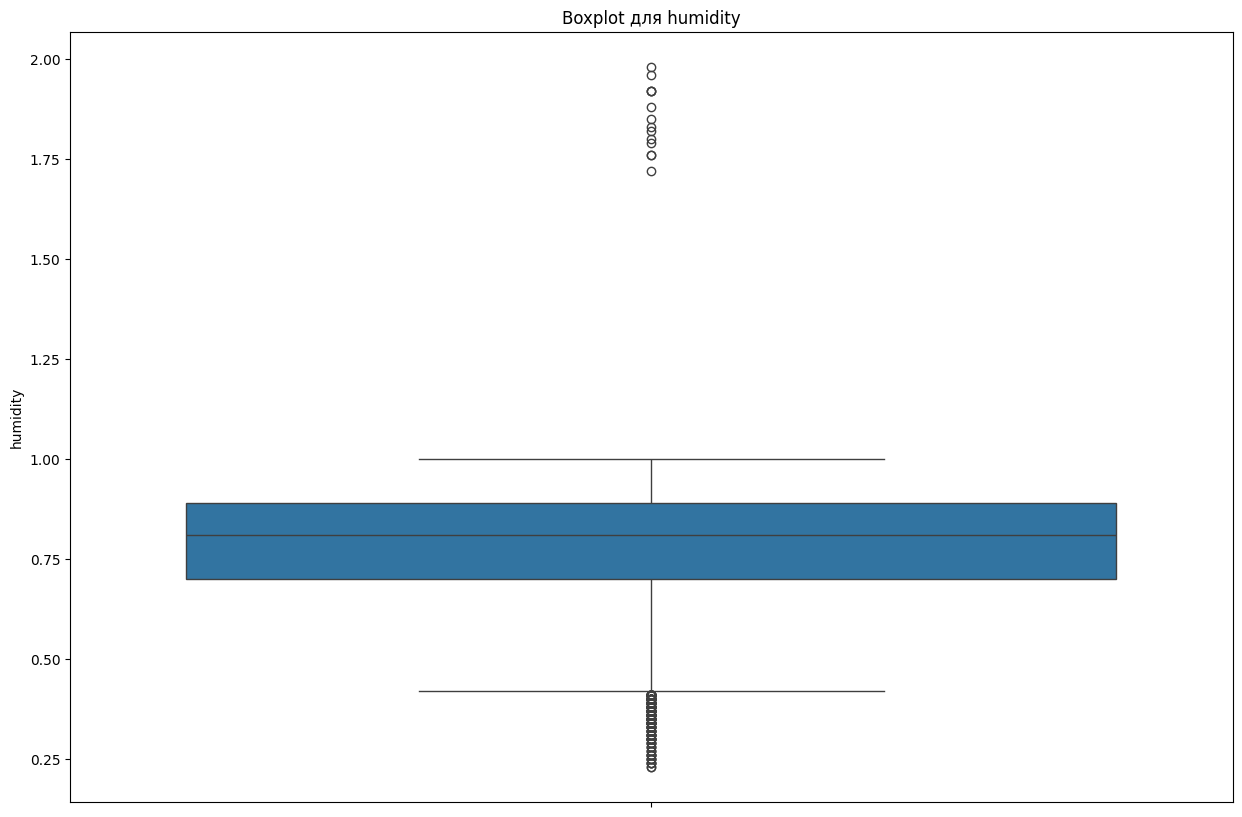

In [ ]:
column = 'humidity'
print("Найдём количество значений-выбросов в данных о влажности воздуха")
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f'Выбросов по методу IQR: {len(outliers)}, {len(outliers)/len(df["windSpeed"])*100:.3f}% от общего кол-ва\n\n')

# Визуализация
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, y=column)
plt.title(f'Boxplot для {column}')
plt.show()

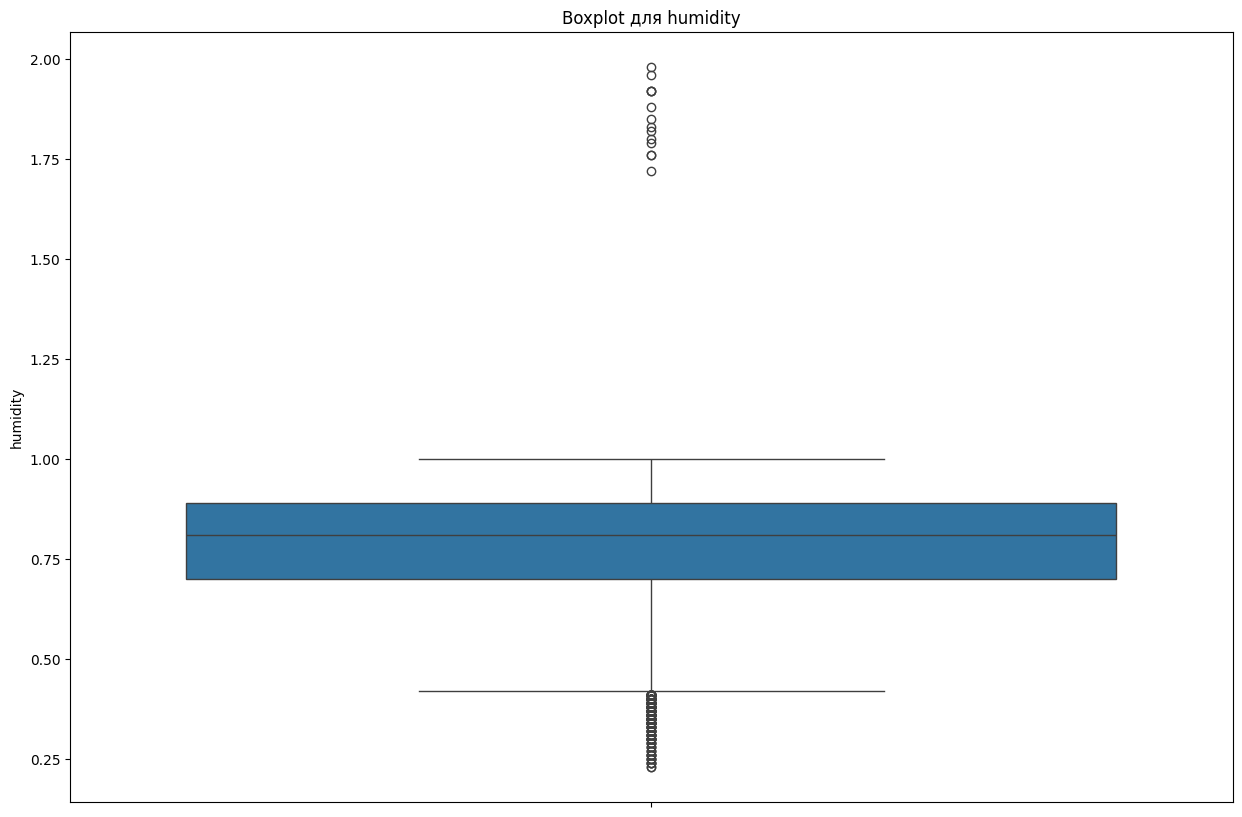

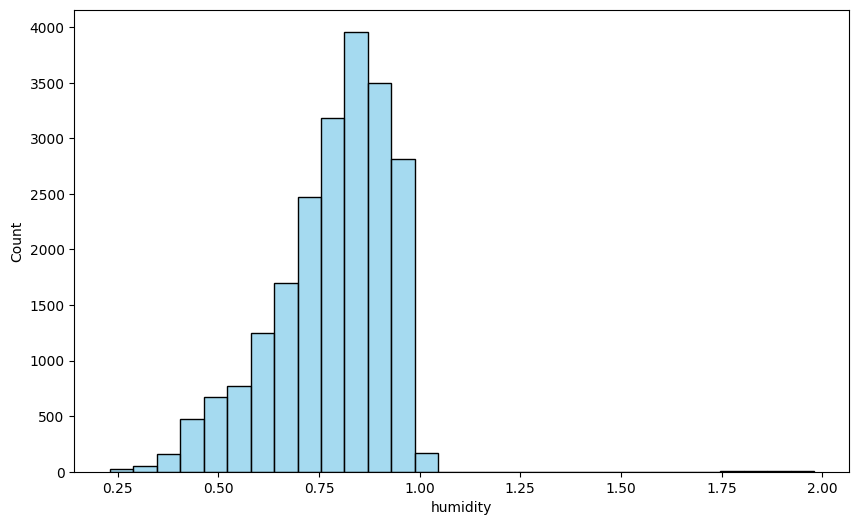

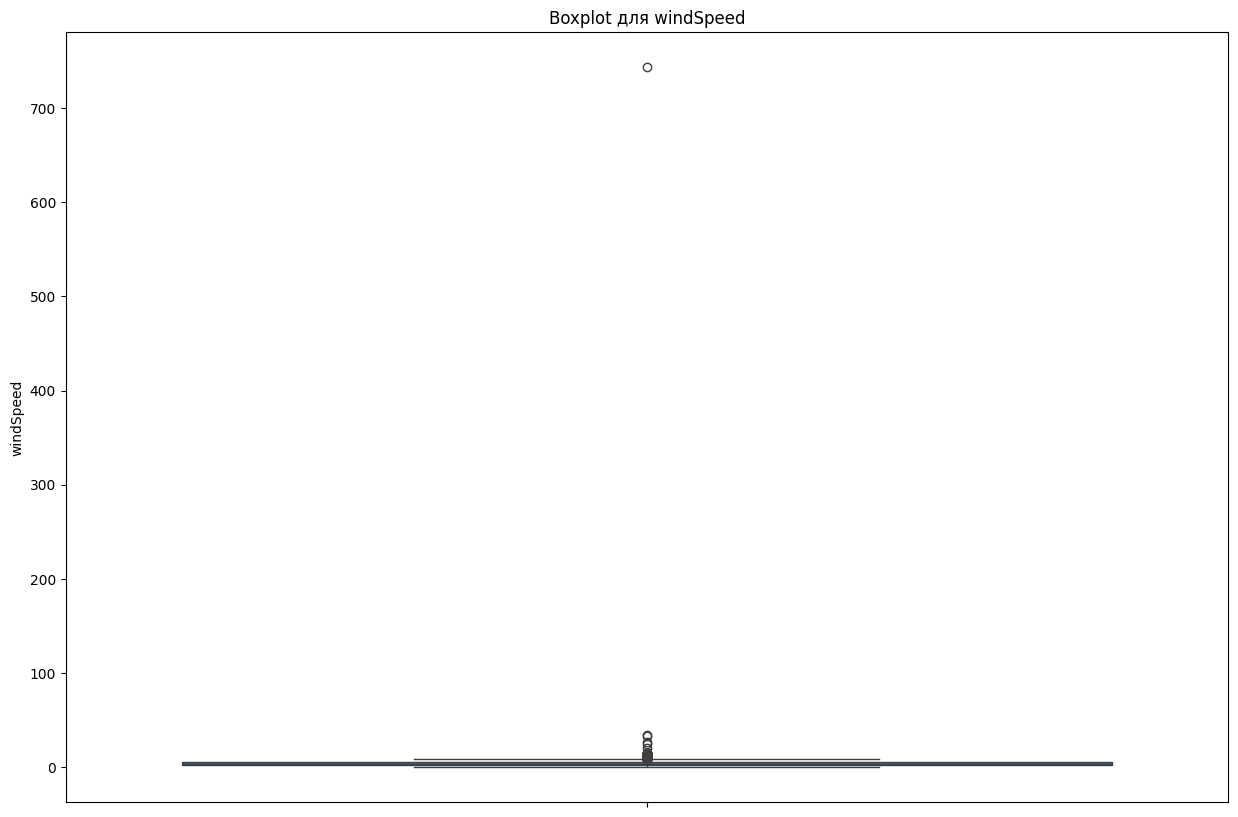

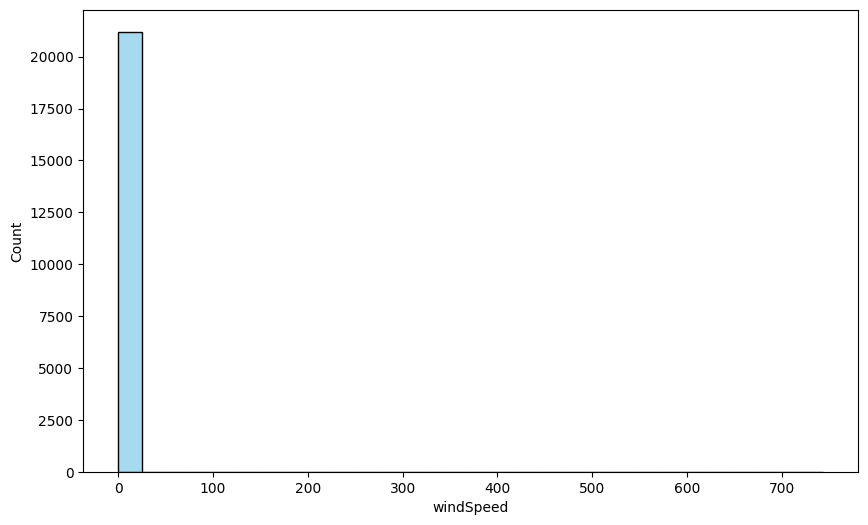

print("По графику видно наличие значений влажности > 1, что невозможно при предполагаемом ограничении значений [0, 1].")

Так же в числовом значении скорости ветра присутствует выброс величиной > 700 м\с, что является установленной ошибкой.


In [ ]:
column1 = "humidity"
column2 = "windSpeed"


plt.figure(figsize=(15, 10))
sns.boxplot(data=df, y=column1)
plt.title(f'Boxplot для {column1}')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df[column1], bins=30, color='skyblue')
#quantity_log = np.log1p(df['humidity'].abs())
#sns.histplot(quantity_log, kde=True);
plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(data=df, y=column2)
plt.title(f'Boxplot для {column2}')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df[column2], bins=30, color='skyblue')
#quantity_log = np.log1p(df['humidity'].abs())
#sns.histplot(quantity_log, kde=True);
plt.show()

print("""print("По графику видно наличие значений влажности > 1, что невозможно при предполагаемом ограничении значений [0, 1].")

Так же в числовом значении скорости ветра присутствует выброс величиной > 700 м\с, что является установленной ошибкой.""")


Гипотезы о humidity
H0: Распределение humidity является нормальным
H1: Распределение humidity НЕ является нормальным
Статистика W: 0.9275
p-value: 6.04e-44
p-value ≤ 0.05: ОТВЕРГАЕМ H0
   Распределение НЕ является нормальным

Гипотезы о windSpeed
H0: Распределение windSpeed является нормальным
H1: Распределение windSpeed НЕ является нормальным
Статистика W: 0.9482
p-value: 8.61e-39
p-value ≤ 0.05: ОТВЕРГАЕМ H0
   Распределение НЕ является нормальным

Гипотезы о windSpeedCorrected
H0: Распределение windSpeedCorrected является нормальным
H1: Распределение windSpeedCorrected НЕ является нормальным
Статистика W: 0.9482
p-value: 8.61e-39
p-value ≤ 0.05: ОТВЕРГАЕМ H0
   Распределение НЕ является нормальным


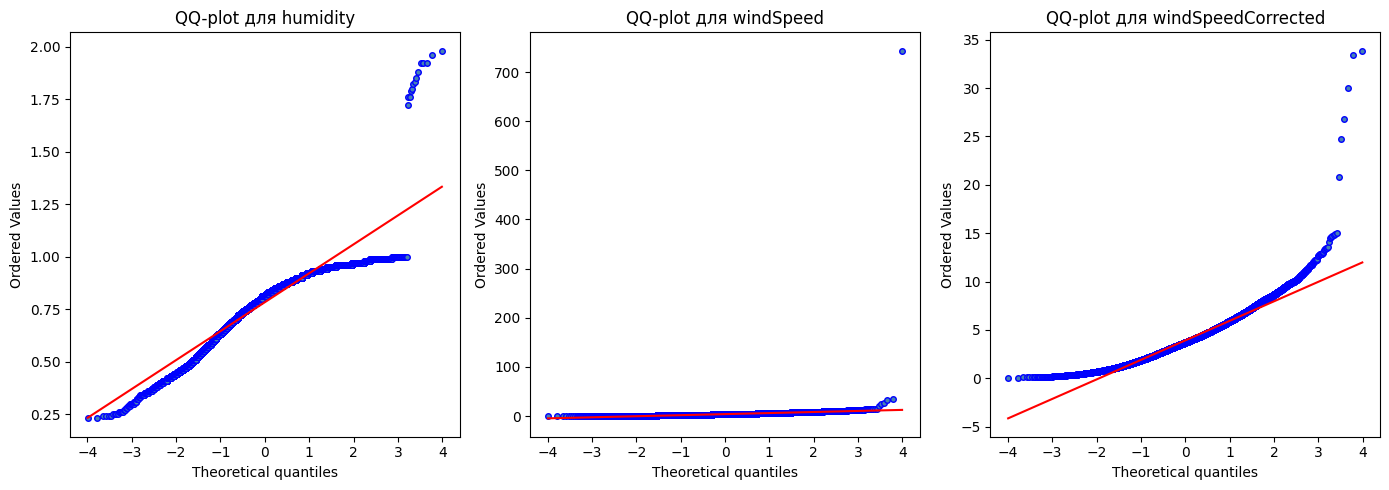

In [ ]:
from scipy import stats
from scipy.stats import shapiro, probplot, mstats

df = pd.read_csv('/content/hourly_weather_data.csv')
df['time'] = pd.to_datetime(df['time'])
df['windSpeedCorrected'] = df['windSpeed'].replace(743.44, 30)

ps = ['humidity', 'windSpeed', 'windSpeedCorrected']
alpha = 0.05

for p in ps:
     data = df[p].dropna()
    # ср арифм
     mean_val = np.mean(data)

    # медиана
     median_val = np.median(data)

    # станд откл
     std_val = np.std(data, ddof=1)

    # асимм
     skew_val = stats.skew(data)

    # эксцесс
     exc = stats.kurtosis(data)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, feature in enumerate(ps):
    # Убираем пропуски
    data = df[feature].dropna()


    #qq cравнение с нормальным распределением
    probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ-plot для {feature}')
    axes[i].get_lines()[0].set_markerfacecolor('steelblue')
    axes[i].get_lines()[0].set_markersize(4)


    #shap-yilka, ограничение в 5000
    if len(data) > 5000:
        data_sample = data.sample(5000, random_state=42)
    else:
        data_sample = data

    statistic, p_value = shapiro(data_sample)

    print(f"\nГипотезы о {feature}")
    print(f"H0: Распределение {feature} является нормальным")
    print(f"H1: Распределение {feature} НЕ является нормальным")
    print(f"Статистика W: {statistic:.4f}")
    print(f"p-value: {p_value:.2e}")

    # Вывод о принятии гипотезы
    if p_value > alpha:
        print(f"p-value > {alpha}: НЕТ оснований отвергнуть H0")
        print(f"   Распределение можно считать нормальным (на уровне {alpha})")
    else:
        print(f"p-value ≤ {alpha}: ОТВЕРГАЕМ H0")
        print(f"   Распределение НЕ является нормальным")

plt.tight_layout()
plt.show()

Выбросы для признака: humidity

1. Метод Z-score (|Z| > 3)
Количество выбросов: 104
Доля выбросов: 0.490% от общего кол-ва


2. Метод IQR
Количество выбросов: 311
Доля выбросов: 1.466% от общего кол-ва



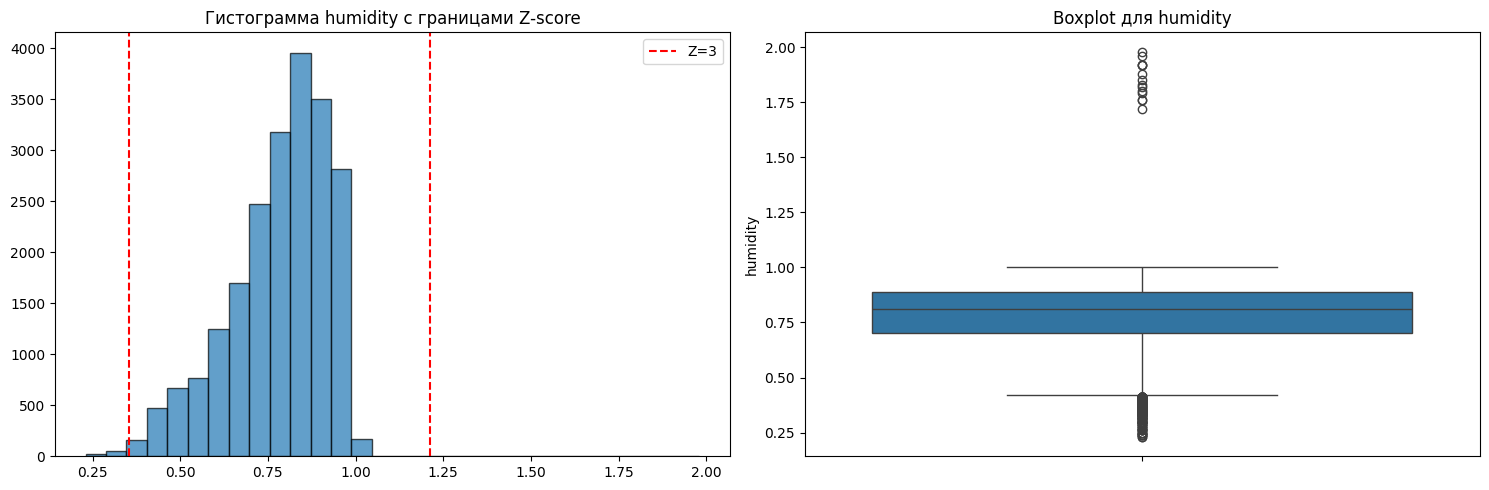



Сравним
Z-score выбросов: 104
IQR выбросов: 311
Разница: 207
Стоит отметить, что метод Z-score нашёл менее реалистичные границы выбросов (верхняя граница > 1), но при этом
большее количество реалистичных значений осталось неисключено, по сравнению с IQR


In [ ]:
column = 'humidity'

print(f"Выбросы для признака: {column}")

print("\n1. Метод Z-score (|Z| > 3)")

z_scores = np.abs(stats.zscore(df[column].dropna()))
threshold_z = 3
outliers_z = df[column][z_scores > threshold_z]

print(f"Количество выбросов: {len(outliers_z)}")
print(f"Доля выбросов: {len(outliers_z)/len(df[column].dropna())*100:.3f}% от общего кол-ва\n")

# Визуализация Z-score
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.hist(df[column].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.axvline(df[column].mean() + 3*df[column].std(), color='r', linestyle='--', label='Z=3')
plt.axvline(df[column].mean() - 3*df[column].std(), color='r', linestyle='--')
plt.title(f'Гистограмма {column} с границами Z-score')
plt.legend()

print("\n2. Метод IQR")

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f'Количество выбросов: {len(outliers_iqr)}')
print(f'Доля выбросов: {len(outliers_iqr)/len(df[column].dropna())*100:.3f}% от общего кол-ва\n')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y=column)
plt.title(f'Boxplot для {column}')
plt.tight_layout()
plt.show()

print("\n")
print("Сравним")
print(f"Z-score выбросов: {len(outliers_z)}")
print(f"IQR выбросов: {len(outliers_iqr)}")
print(f"Разница: {abs(len(outliers_z) - len(outliers_iqr))}")

print("""Стоит отметить, что метод Z-score нашёл менее реалистичные границы выбросов (верхняя граница > 1), но при этом
большее количество реалистичных значений осталось неисключено, по сравнению с IQR""")

Так как признак humidity не подчиняется нормальному распределению, применим MinMaxScaler



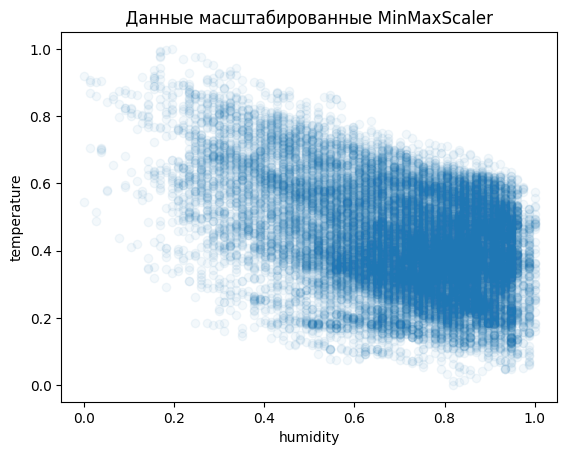



Используем верхние 91% значений.


k = 5:
По среднему расстоянию:
Пороговое значение:  0.006
Удалено записей: 1909 из 21208

По расстоянию до k-го соседа:
Пороговое значение:  0.0097
Удалено записей: 1868 из 21208




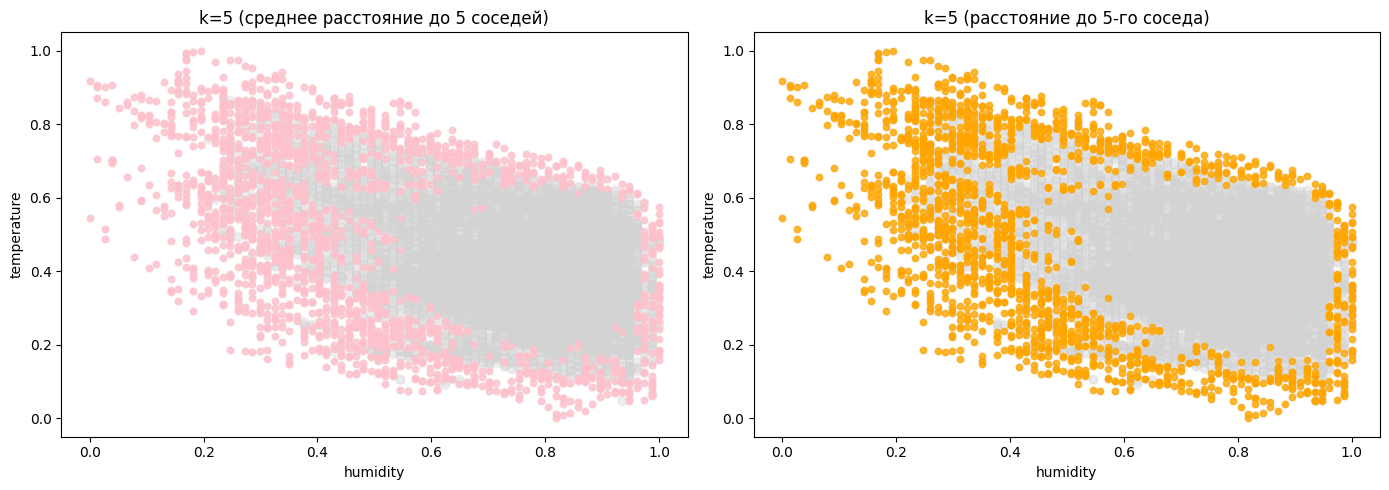


k = 7:
По среднему расстоянию:
Пороговое значение:  0.008
Удалено записей: 1909 из 21208

По расстоянию до k-го соседа:
Пороговое значение:  0.013
Удалено записей: 1905 из 21208




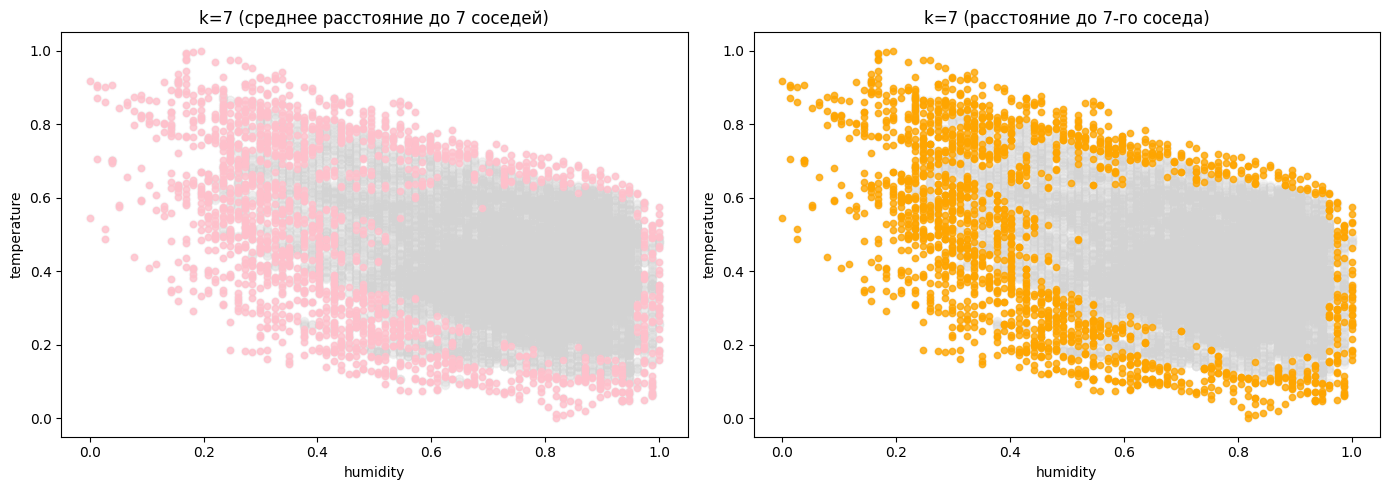


k = 10:
По среднему расстоянию:
Пороговое значение:  0.0098
Удалено записей: 1909 из 21208

По расстоянию до k-го соседа:
Пороговое значение:  0.0135
Удалено записей: 1905 из 21208




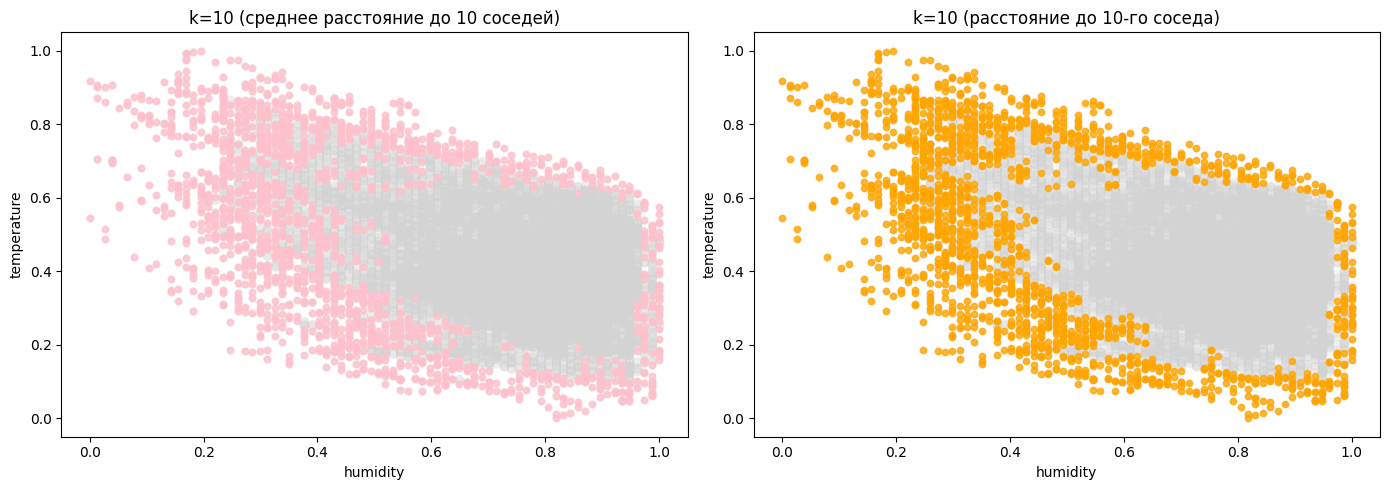

In [ ]:
# Задание 4. Метод локальной плотности

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
import random

# Загрузка данных
df = pd.read_csv('/content/hourly_weather_data.csv')

df['humidity'] = df['humidity'].clip(upper=1)

print("""Так как признак humidity не подчиняется нормальному распределению, применим MinMaxScaler\n""")
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['temperature', 'humidity']].values)

anom_percentile = random.randint(90, 99)

plt.scatter(scaled_data[:, 1], scaled_data[:, 0], alpha=0.05)
plt.title(' Данные масштабированные MinMaxScaler ')
plt.xlabel('humidity')
plt.ylabel('temperature')
plt.xticks(rotation=0)
plt.show()

print(f"\n\nИспользуем верхние {anom_percentile}% значений.\n")

def NeibFind(k, scaled_data):
    global anom_percentile


    print(f'\nk = {k}:')
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    nn.fit(scaled_data)
    distances, indices = nn.kneighbors(scaled_data)

    # mean_to_k
    mean_distance = np.mean(distances[:, 1:], axis=1)

    # dtk
    distance_to_kth = distances[:, -1]

    # lim mean dist
    anomaly_criteria_mean = np.percentile(mean_distance, anom_percentile)
    filter_mean = mean_distance <= anomaly_criteria_mean
    filtered_data_mean = scaled_data[filter_mean]

    print("По среднему расстоянию:")
    print("Пороговое значение: ", round(anomaly_criteria_mean, 4))
    print(f"Удалено записей: {len(scaled_data) - len(filtered_data_mean)} из {len(scaled_data)}\n")

    # lim dtk
    anomaly_criteria_dtk = np.percentile(distance_to_kth, anom_percentile)
    filter_kth = distance_to_kth <= anomaly_criteria_dtk
    filtered_data_kth = scaled_data[filter_kth]

    print("По расстоянию до k-го соседа:")
    print("Пороговое значение: ", round(anomaly_criteria_dtk, 4))
    print(f"Удалено записей: {len(scaled_data) - len(filtered_data_kth)} из {len(scaled_data)}\n")
    print()

    # Графики
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # mean dist scatter
    axes[0].scatter(scaled_data[:, 1], scaled_data[:, 0], alpha=0.1, c='lightgray')
    axes[0].scatter(scaled_data[~filter_mean, 1], scaled_data[~filter_mean, 0],
                    alpha=0.8, c='pink', s=20)
    axes[0].set_title(f'k={k} (среднее расстояние до {k} соседей)')
    axes[0].set_xlabel('humidity')
    axes[0].set_ylabel('temperature')

    # dtk scatter
    axes[1].scatter(scaled_data[:, 1], scaled_data[:, 0], alpha=0.1, c='lightgray')
    axes[1].scatter(scaled_data[~filter_kth, 1], scaled_data[~filter_kth, 0],
                    alpha=0.8, c='orange', s=20)
    axes[1].set_title(f'k={k} (расстояние до {k}-го соседа)')
    axes[1].set_xlabel('humidity')
    axes[1].set_ylabel('temperature')

    plt.tight_layout()
    plt.show()

# Вызов функции для разных k
NeibFind(5, scaled_data)
NeibFind(7, scaled_data)
NeibFind(10, scaled_data)
